In [1]:
import tensorflow as tf
# 학습시간, 결석일수에 따른 자격증 시험 합격 여부 예제
# 성적데이터.csv 파일을 열어 padans의 데이터프레임으로 변환
import pandas as pd

df = pd.read_csv('성적데이터.csv')

# 독립변수, 종속변수 분리
# 독립변수 중 hour과 absent만 빼내서 X로
# 종속변수는 score
X = df[['hour', 'absent']]
# score가 60이상이면 1로, 미만이면 0으로 변경. 열이름은 pass
def convert_pass(x):
	return 1 if x >= 60 else 0

import numpy as np

# score를 이용해서 합격/불합격으로 변환
df['pass1'] = df['score'].apply(convert_pass)
df['pass2'] = df['score'].apply(lambda x:1 if x >= 60 else 0)

df['pass3'] = np.where(df['score'] >= 60, 1, 0)

df[['score', 'pass1', 'pass2', 'pass3']]
y = df['pass3']

In [2]:
# 모델 설계
# 방법1. 레이어를 리스트로 한번에 넣어줌 : 직관적
# 정규화를 해주는 객체
# -1은 데이터의 마지막 차원을 기준으로 정규화 
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(X.values.astype('float32'))
model1 = tf.keras.models.Sequential([
	normalizer, #입력층으로 정규화 진행
	tf.keras.layers.Dense(4, activation='relu'),
	tf.keras.layers.Dense(8, activation='relu'),
	tf.keras.layers.Dense(4, activation='relu'),
	tf.keras.layers.Dense(1, activation='sigmoid')
])
# 방법2. add() 메소드를 통해 레이어를 추가 : 동적으로 작업
model2 = tf.keras.models.Sequential()
model2.add(tf.keras.layers.Dense(4, activation='relu', input_shape=(2,)))
model2.add(tf.keras.layers.Dense(8, activation='relu'))
model2.add(tf.keras.layers.Dense(4, activation='relu'))
model2.add(tf.keras.layers.Dense(1, activation='sigmoid'))

c:\Users\hi6\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
# 모델 설정
# 옵티마이저 설정 : 가중치를 업데이트 하는 방법을 설정(adam, sgv, softmax등)
# 손실함수 : 오차 계산하는 방법을 설정(mse, binary_crossentropy 등)
# 평가지표 : 학습 중 사용자에게 보여줄 성적표(accuracy 등)

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [4]:
# 학습
history = model1.fit(X, y, epochs=1000, batch_size=4, validation_split=0.2, verbose=0)

In [5]:
# (공부시간, 결석일) : (5,0), (10,5), (8,1) 합격여부를 예측
predictions = model1.predict(np.array([[5,0],[10,5],[8,1]]))
print(f'학습시간 : {5}, 결석일 : {0}, 합격확률 :{ predictions[0][0]:.4f}')
print(f'학습시간 : {10}, 결석일 : {5}, 합격확률 :{ predictions[1][0]:.4f}')
print(f'학습시간 : {8}, 결석일 : {1}, 합격확률 :{ predictions[2][0]:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
학습시간 : 5, 결석일 : 0, 합격확률 :0.0000
학습시간 : 10, 결석일 : 5, 합격확률 :0.0003
학습시간 : 8, 결석일 : 1, 합격확률 :1.0000


In [6]:
# accuracy : 훈련 데이터 정확도
# loss : 훈련 데이터 오차
# val_accuracy : 테스트(검증) 데이터 정확도
# val_loss : 테스트(검증) 데이터 오차

print(history.history.keys())


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


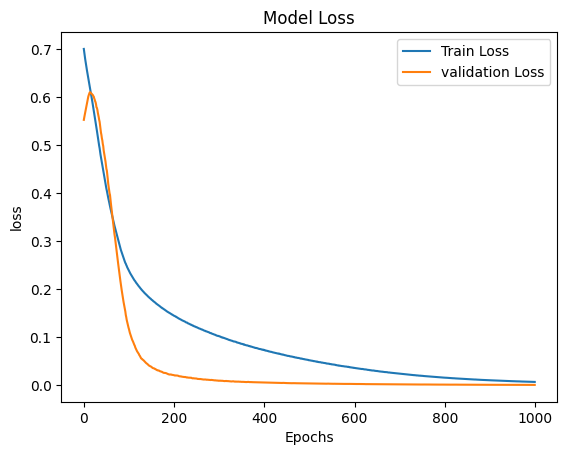

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.show()


In [12]:
# 최종 평가
# 실제 데이터라고 가정
df2 = pd.DataFrame({
  'hour': [4, 5.5, 8.5, 6], 
  'absent' : [0, 3, 3, 0], 
  'pass' : [0, 0, 1, 1]

})

X_test = df2[['hour', 'absent']].values
y_test = df2['pass'].values


test_loss, test_acc = model1.evaluate(X_test, y_test.reshape(4,1))
print(f'예측 정확도 : {test_acc:.4f}, 오차 : {test_loss:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.7500 - loss: 1.5632
예측 정확도 : 0.7500, 오차 : 1.5632


In [15]:
# 틀렸을만한 2개를 확인하는 코드
model1.predict(np.array([[5.5,3], [8.5,3]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


array([[0.9970466],
       [0.6517346]], dtype=float32)

In [17]:
# 모델 저장
# 전체 저장
model1.save('my_model.h5')

In [18]:
load_model = tf.keras.models.load_model('my_model.h5')
load_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (4, 2)                 │             5 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (4, 4)                 │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (4, 8)                 │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (4, 4)                 │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (4, 1)                 │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100 (408.00 B)

 Trainable params: 93 (372.00 B)

 Non-trainable params: 5 (24.00 B)

 Optimizer params: 2 (12.00 B)